# 3.1 ID Pattern for Language Model

In this work, we use the RoBERTa architecture to examine intrinsic dimensionality patterns in the NLP domain. Specifically, we analyze how the ID evolves across different layers of the model when processing texts from distinct domains (e.g., CNN news articles vs. Twitter posts). This allows to investigate the representational dynamics of a transformer-based architecture, extending the study of ID beyond CNNs and MLPs as suggested.


In [ ]:
import sys
sys.path.append('/content')
from utils import *

In [2]:
import numpy as np
from scipy.stats import pearsonr
from sklearn import linear_model
from scipy.spatial.distance import pdist, squareform
from tqdm import tqdm
import random
from transformers import RobertaTokenizer, RobertaModel, DataCollatorWithPadding
from datasets import load_dataset, concatenate_datasets
from torch.utils.data import DataLoader
import torch
import matplotlib.pyplot as plt
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
def tokenization(batch, tokenizer, text_key, max_length=512):
    return tokenizer(batch[text_key], truncation=True, padding=True, max_length=max_length)

def compute_id_nlp(X,model,tokenizer,text_key,fraction=0.9,verbose=False,device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tokenize_fn = lambda batch: tokenization(batch, tokenizer, text_key, max_length=512)
    dataset = X.map(tokenize_fn, batched=True,remove_columns=X.column_names)
    collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")
    dataloader = DataLoader(dataset, batch_size=10,
                            shuffle=True, collate_fn=collator, num_workers=0)
    hidden_states = []
    for i, data in tqdm(enumerate(dataloader,0)):
        data = {k: v.to(device) for k, v in data.items()}
        with torch.no_grad():
            output = model(**data)
        batch_hidden_states = [h.detach().cpu() for h in output.hidden_states]
        if i == 0:
            hidden_states = batch_hidden_states
        else:
            hidden_states = [torch.cat([h1,h2], dim=0) for h1,h2 in zip(hidden_states,batch_hidden_states)]
    hidden_states_cls = [h[:,0,:].numpy() for h in hidden_states[1:]]


    ids = []
    for h in hidden_states_cls:
        id = twonn_id(torch.tensor(h,dtype=torch.float32),device,batch=256)
        ids.append(id)
    return ids


In [ ]:
# Sample subsets from the CNN/DailyMail dataset and compute intrinsic dimensionality (ID)
# using RoBERTa representations. Results are averaged across multiple runs to obtain
# mean and standard deviation of ID estimates per layer.

tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
model = RobertaModel.from_pretrained('roberta-base',output_hidden_states=True).to(device)
model.eval()

n = 250
all_ids_cnn = []
run = 10
ds_cnn = load_dataset("cnn_dailymail",'3.0.0',split="train")
for i in range(run):
    indices = random.sample(range(len(ds_cnn)), n)
    dataset = ds_cnn.select(indices)
    ids = compute_id_nlp(dataset,model,tokenizer,text_key="article")
    all_ids_cnn.append(ids)

all_ids_cnn = np.array(all_ids_cnn)
mean_ids_cnn = np.mean(all_ids_cnn, axis=0)
std_ids_cnn = np.std(all_ids_cnn, axis=0)
layers_cnn = np.arange(len(mean_ids_cnn))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

25it [00:20,  1.24it/s]


Map:   0%|          | 0/250 [00:00<?, ? examples/s]

25it [00:20,  1.24it/s]


Map:   0%|          | 0/250 [00:00<?, ? examples/s]

25it [00:20,  1.25it/s]


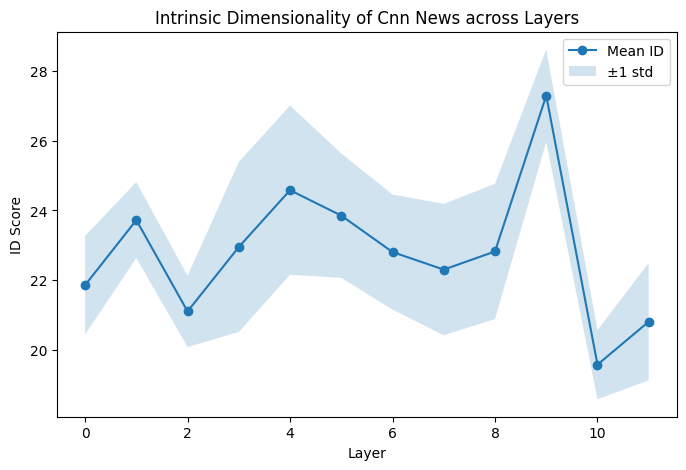

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(layers_cnn, mean_ids_cnn, marker="o", label="Mean ID")

plt.fill_between(layers_cnn, mean_ids_cnn-std_ids_cnn, mean_ids_cnn+std_ids_cnn, alpha=0.2, label="±1 std")

plt.xlabel("Layer")
plt.ylabel("ID Score")
plt.title("Intrinsic Dimensionality of Cnn News across Layers")
plt.legend()
plt.show()

The intrinsic dimensionality of CNN news text remains relatively stable across most layers, fluctuating around the low-20s range. A sharp peak appears near layer 9, followed by a steep drop in the final layers. This suggests that while the model expands and maintains semantic structure steadily through the middle layers, it later undergoes strong compression, converging toward more compact and task-oriented representations.

In [ ]:
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
model = RobertaModel.from_pretrained('roberta-base',output_hidden_states=True).to(device)
model.eval()

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


RobertaModel(
  (embeddings): RobertaEmbeddings(
    (word_embeddings): Embedding(50265, 768, padding_idx=1)
    (position_embeddings): Embedding(514, 768, padding_idx=1)
    (token_type_embeddings): Embedding(1, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): RobertaEncoder(
    (layer): ModuleList(
      (0-11): 12 x RobertaLayer(
        (attention): RobertaAttention(
          (self): RobertaSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): RobertaSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (dr

In [ ]:
# Load and concatenate six TweetEval datasets, sample subsets multiple times,
# compute intrinsic dimensionality (ID) with tokenization_tweet,
# and aggregate mean/std ID across RoBERTa layers.

configs = ["emoji", "emotion", "hate", "irony", "offensive", "sentiment"]

datasets_tweet = []
for cfg in configs:
    ds_tweet = load_dataset("cardiffnlp/tweet_eval", cfg, split="train")
    ds_tweet = ds_tweet.remove_columns([c for c in ds_tweet.column_names if c != "text"])
    datasets_tweet.append(ds_tweet)

ds_all_tweet = concatenate_datasets(datasets_tweet)


n = 250
all_ids_tweet = []
run = 10

for i in range(run):
    indices = random.sample(range(len(ds_all_tweet)), n)
    dataset = ds_all_tweet.select(indices)
    ids_tweet = compute_id_nlp(dataset, model, tokenizer, text_key="text")
    all_ids_tweet.append(ids_tweet)


all_ids_tweet = np.array(all_ids_tweet)
mean_ids_tweet = np.mean(all_ids_tweet, axis=0)
std_ids_tweet = np.std(all_ids_tweet, axis=0)
layers_tweet = np.arange(len(mean_ids_tweet))


Map:   0%|          | 0/250 [00:00<?, ? examples/s]

25it [00:17,  1.41it/s]


Map:   0%|          | 0/250 [00:00<?, ? examples/s]

25it [00:22,  1.12it/s]


Map:   0%|          | 0/250 [00:00<?, ? examples/s]

...

25it [00:15,  1.64it/s]


Map:   0%|          | 0/250 [00:00<?, ? examples/s]

25it [00:28,  1.15s/it]


Map:   0%|          | 0/250 [00:00<?, ? examples/s]

25it [00:25,  1.03s/it]


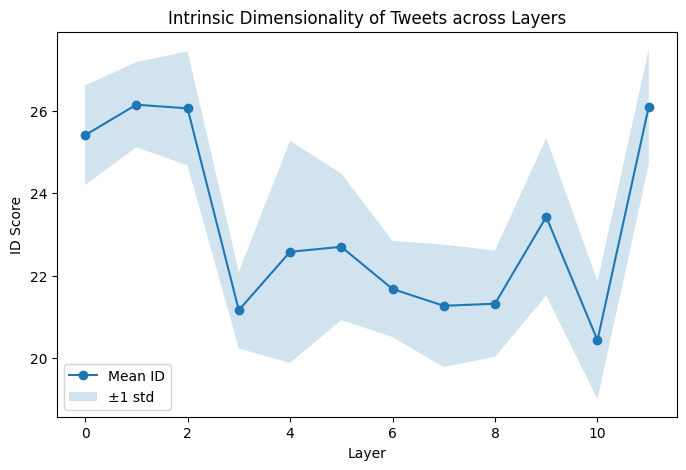

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(layers_tweet, mean_ids_tweet, marker="o", label="Mean ID")

plt.fill_between(layers_tweet, mean_ids_tweet-std_ids_tweet, mean_ids_tweet+std_ids_tweet, alpha=0.2, label="±1 std")

plt.xlabel("Layer")
plt.ylabel("ID Score")
plt.title("Intrinsic Dimensionality of Tweets across Layers")
plt.legend()
plt.show()

For Twitter text, the ID starts at a higher value (around 27–28), peaks in the early layers, and then drops sharply by layer 3. After this sudden decline, the ID stabilizes at a mid-level plateau, before showing another increase at the final layer. This pattern reflects that tweets, being shorter and noisier, initially trigger a broad expansion in representation, but the model quickly compresses this information. The later rise may indicate residual variability or instability in handling informal, irregular text.

# 3.2 Simulation with known ID

In [9]:
!pip install pytorch-pretrained-biggan
from pytorch_pretrained_biggan import (BigGAN, one_hot_from_names, truncated_noise_sample)
import nltk
import torch
import numpy as np
from scipy.stats import pearsonr
from sklearn import linear_model
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist,squareform
from tqdm import tqdm
import random
from torch.utils.data import TensorDataset, DataLoader
import torchvision.models as models
import torch.nn.functional as F
from functools import partial
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

## 1. Experimental Setup: Generative Models & ID Estimators

We initialize the **BigGAN** generator and define the helper functions.
* **Generators:** We define two types of manifolds:
    * `sample_restricted_z`: A non-linear image manifold created by restricting the BigGAN latent space.
    * `gen`: A linear hyperplane with Gaussian noise (for baseline benchmarking).

    These two complementary approaches provide distinct benchmarks for evaluating ID estimation methods.


In [7]:
biggan = BigGAN.from_pretrained('biggan-deep-128')
biggan.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# --- Synthetic Data Generation ---
# --- Method A：Linear Factor Model Sampling ---
def gen(n, d, p, noise_dim=0, sigma=1.0):
    Z = np.random.randn(n, d)
    A = np.random.randn(d, p)
    X = Z @ A
    if noise_dim > 0:
        noise = sigma * np.random.randn(n, noise_dim)
        X = np.concatenate([X, noise], 1)
    return torch.from_numpy(X).float()

# --- Method B：GAN-based Restricted Latent Subspace Sampling ---
def sample_restricted_z(num_samples, d, z_dim=128, truncation=0.4):
    z = torch.zeros(num_samples, z_dim)
    z[:, :d] = torch.from_numpy(truncated_noise_sample(batch_size=num_samples, dim_z=d, truncation=truncation))
    return z

def get_sample(model,z,labels,trunc=0.4,batch_size=64,device=None):
    if device is None:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = model.to(device).eval()
    z = z.to(device)
    labels = labels.to(device)

    outs = []

    with torch.inference_mode():
        for i in range(0, z.size(0), batch_size):
            zi = z[i:i+batch_size]
            yi = labels[i:i+batch_size]
            out = model(zi, yi, trunc)
            outs.append(out)
        out = torch.cat(outs, dim=0)
        out = (out + 1) / 2
    return out.to('cpu')



100%|██████████| 630/630 [00:00<00:00, 2222381.43B/s]


## 2. Validation: Latent vs. Estimated ID

We verify the estimators by generating BigGAN images from latent vectors of known dimension. Ideally, the estimated ID of the output images should correlate linearly with the input.

computing estimates change with increasing true ID...: 100%|██████████| 61/61 [15:50<00:00, 15.59s/it]


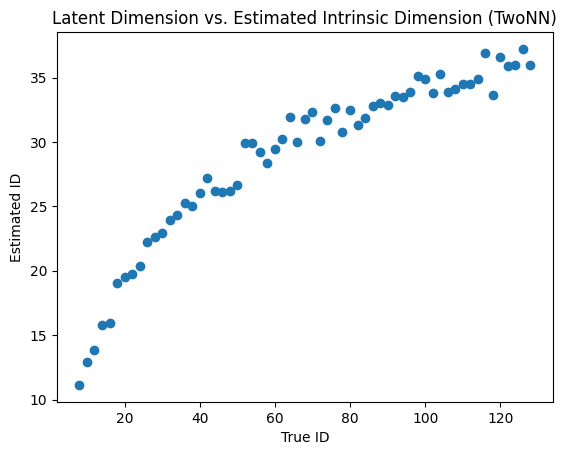

Spearman's correlation coefficient: 0.985


In [ ]:
true_ids = [i for i in range(8,129,2)]
estimate_ids = []
for id in tqdm(true_ids,desc="computing estimates change with increasing true ID..."):
    z = sample_restricted_z(num_samples=2000, d=id)
    labels = one_hot_from_names(["basenji"] * 2000, batch_size=2000)
    labels = torch.from_numpy(labels)
    out = get_sample(biggan,z,labels)
    X = out.view(out.size(0), -1)
    estimate_id = twonn_id(X,device)
    estimate_ids.append(estimate_id)
plt.scatter(true_ids,estimate_ids)
plt.xlabel("True ID")
plt.ylabel("Estimated ID")
plt.title("Latent Dimension vs. Estimated Intrinsic Dimension (TwoNN)")
plt.show()

from scipy.stats import spearmanr
spearman_corr, p_s = spearmanr(true_ids, estimate_ids)
print("Spearman's correlation coefficient: {:.3f}".format(spearman_corr))

### Observation
The estimated ID increases monotonically with the true ID, showing that the estimator captures the overall growth trend. The high Spearman’s correlation coefficient (ρ = 0.98) further confirms a strong rank-order relationship between true and estimated IDs.

## 3. Robustness Analysis: Sample Size (Linear Baseline)

We test how the sample size ($N$) affects the stability of TwoNN vs. MLE on a simple linear manifold. MLE typically exhibits higher bias at low sample sizes.

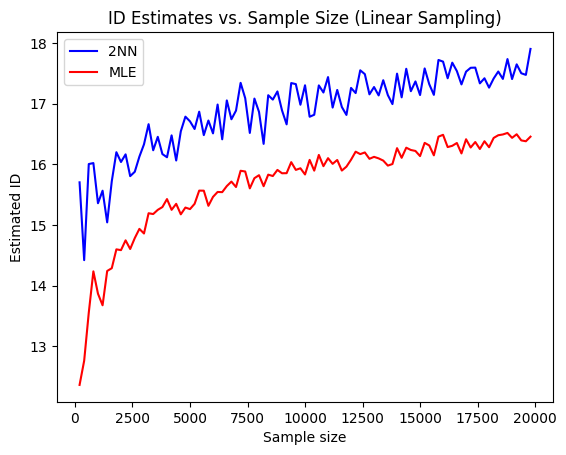

Synthetic dataset generated with intrinsic dimension = 16, embedded in 128-dimensional ambient space, plus 64 Gaussian noise dimensions (ambient dimension = 192 in total)


In [ ]:
# --- ID Estimates vs. Sample Size (Linear Sampling) ---
sample_sizes = [i for i in range(200,20000,200)]
estimate_ids_2nn = []
estimate_ids_mle = []
for size in sample_sizes:
    X = gen(size,16,128,noise_dim=64)
    estimate_ids_2nn.append(twonn_id(X,device,batch=512))
    estimate_ids_mle.append(mle_id(X,device,batch=512))
plt.plot(sample_sizes,estimate_ids_2nn, color='blue',label="2NN")
plt.plot(sample_sizes,estimate_ids_mle,color='red',label="MLE")
plt.xlabel("Sample size")
plt.ylabel("Estimated ID")
plt.title("ID Estimates vs. Sample Size (Linear Sampling)")
plt.legend()
plt.show()

print("Synthetic dataset generated with intrinsic dimension = 16, embedded in 128-dimensional ambient space, plus 64 Gaussian noise dimensions (ambient dimension = 192 in total)")




## 4. Robustness Analysis: Sample Size (Image Manifold)

We repeat the robustness test on the complex BigGAN manifold.
**Note:** We use `Adaptive Average Pooling` to downsample images before ID estimation. This reduces the ambient pixel noise while preserving the manifold structure.

100%|██████████| 37/37 [33:33<00:00, 54.41s/it] 


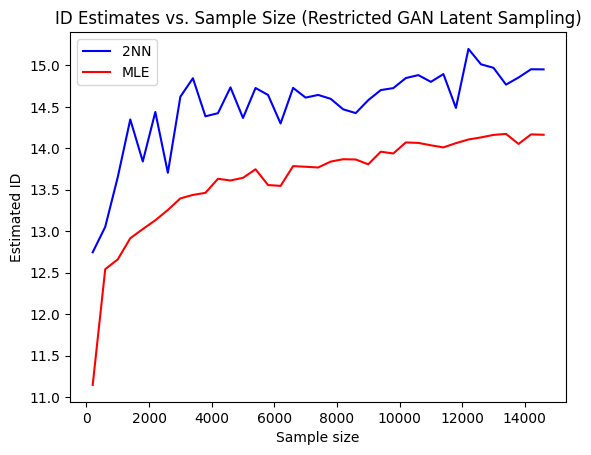

In [ ]:
sample_sizes = [i for i in range(200,15000,400)]
#true_ids = [16,32,64,128]

estimate_ids_2nn = []
estimate_ids_mle = []

for sample_size in tqdm(sample_sizes):
    z = sample_restricted_z(num_samples=sample_size, d=16)
    labels = one_hot_from_names(["basenji"] * sample_size, batch_size=sample_size)
    labels = torch.from_numpy(labels)
    out = get_sample(biggan,z,labels)
    X = F.adaptive_avg_pool2d(out,32).flatten(1)
    estimate_ids_2nn.append(twonn_id(X,device,batch=512))
    estimate_ids_mle.append(mle_id(X,device,batch=512))

plt.plot(sample_sizes,estimate_ids_2nn, color='blue',label="2NN")
plt.plot(sample_sizes,estimate_ids_mle,color='red',label="MLE")
plt.xlabel("Sample size")
plt.ylabel("Estimated ID")
plt.title("ID Estimates vs. Sample Size (Restricted GAN Latent Sampling)")
plt.legend()
plt.show()



### Observation

*   In the synthetic dataset experiment, the true intrinsic dimensionality (ID) is 16. As the sample size increases, both the 2NN and MLE estimators gradually approach this value. With small sample sizes, the estimates are highly variable (especially for 2NN), but with more data the estimates stabilize and converge closer to the ground-truth ID. Compared to 2NN, the MLE estimator produces smoother and more stable estimates, although it converges slightly slower.
*   Advice for future research: Reliable ID estimation requires sufficiently large sample sizes. Using too few samples can lead to underestimation and instability, while larger datasets yield more accurate estimates that better reflect the true underlying dimensionality.







## 5. Robustness Analysis: $p \gg n$ & $n \gg p$

**Experimental Setup:**
* **$p \gg n$ (Curse of Dimensionality):** We use $N=1,000$ samples in a $P=7,000$ dimensional space.
* **$n \gg p$ (Ideal Regime):** We use $N=20,000$ samples in the same space.

**Outcome:**
We use statistical tests (t-test, Cohen's d) to determine if there is a significant discrepancy between these two regimes. This provides advice for future research on the reliability of ID estimation in undersampled conditions.

/tmp/ipython-input-491079359.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, patch_artist=True)


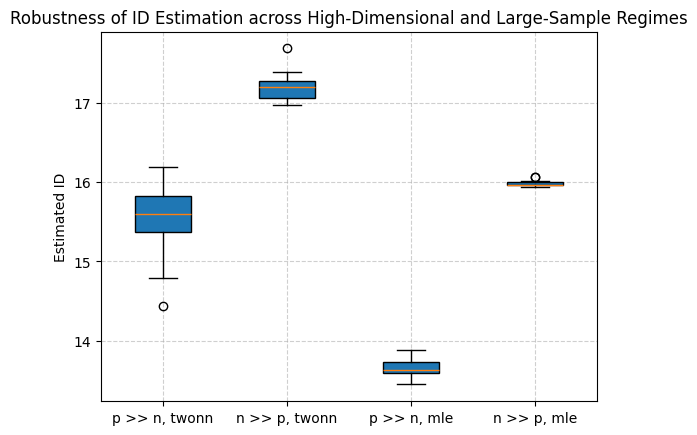

id measured by twonn:
p>>n:  mean=15.528, std=0.449
n>>p:  mean=17.192, std=0.170
t-test: t=-15.51, p=4.09e-14
Cohen's d = 4.90
*************************
id measured by mle:
p>>n:  mean=13.656, std=0.120
n>>p:  mean=15.977, std=0.036
t-test: t=-82.68, p=2.57e-29
Cohen's d = 26.15


In [ ]:
d, p = 16, 5000
noise_dim, sigma = 2000, 1.0
R = 20 # Repetitions for statistical stability


# --- 1. Generate Data for Two Regimes ---

# Regime 1: p >> n (The "High-Dim, Low-Sample" case)
# n=1000, p=7000. Dimension dominates sample size.

ids_small_2nn = [twonn_id(gen(1000, d, p, noise_dim, sigma),device,batch=512) for _ in range(R)]
ids_small_mle = [mle_id(gen(1000, d, p, noise_dim, sigma),device,k=15,batch=512) for _ in range(R)]

# Regime 2: n >> p (The "Large Sample" case)
# n=20000, p=7000. Sample size dominates dimension.

ids_large_2nn = [twonn_id(gen(20000, d, p, noise_dim, sigma),device,batch=512) for _ in range(R)]
ids_large_mle = [mle_id(gen(20000, d, p, noise_dim, sigma),device,k=15,batch=512) for _ in range(R)]


# --- 2. Visualization Comparison ---

data = [ids_small_2nn, ids_large_2nn,ids_small_mle,ids_large_mle]
labels = ["p >> n, twonn", "n >> p, twonn", "p >> n, mle", "n >> p, mle"]

plt.boxplot(data, labels=labels, patch_artist=True)
plt.ylabel("Estimated ID")
plt.title("Robustness of ID Estimation across High-Dimensional and Large-Sample Regimes")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# --- 3. Statistical Quantification ---

from scipy.stats import ttest_ind
ids_small_2nn = np.array(ids_small_2nn)
ids_large_2nn = np.array(ids_large_2nn)
print("id measured by twonn:")
print("p>>n:  mean={:.3f}, std={:.3f}".format(ids_small_2nn.mean(), ids_small_2nn.std(ddof=1)))
print("n>>p:  mean={:.3f}, std={:.3f}".format(ids_large_2nn.mean(), ids_large_2nn.std(ddof=1)))

t, pval = ttest_ind(ids_small_2nn, ids_large_2nn, equal_var=False)
print("t-test: t={:.2f}, p={:.2e}".format(t, pval))

pooled_sd = np.sqrt(((ids_small_2nn.var(ddof=1) + ids_large_2nn.var(ddof=1)) / 2))
cohen_d = (ids_large_2nn.mean() - ids_small_2nn.mean()) / pooled_sd
print("Cohen's d = {:.2f}".format(cohen_d))

print("*"*25)
ids_small_mle = np.array(ids_small_mle)
ids_large_mle = np.array(ids_large_mle)
print("id measured by mle:")
print("p>>n:  mean={:.3f}, std={:.3f}".format(ids_small_mle.mean(), ids_small_mle.std(ddof=1)))
print("n>>p:  mean={:.3f}, std={:.3f}".format(ids_large_mle.mean(), ids_large_mle.std(ddof=1)))

t, pval = ttest_ind(ids_small_mle, ids_large_mle, equal_var=False)
print("t-test: t={:.2f}, p={:.2e}".format(t, pval))

pooled_sd = np.sqrt(((ids_small_mle.var(ddof=1) + ids_large_mle.var(ddof=1)) / 2))
cohen_d = (ids_large_mle.mean() - ids_small_mle.mean()) / pooled_sd
print("Cohen's d = {:.2f}".format(cohen_d))



### Observation

*   When n >> p, both 2NN and MLE recover the true ID (=16) reasonably well. MLE is more robust to noise in this regime, showing higher accuracy and smaller variance.
*   When p >> n, MLE method deviate from the true ID; MLE tends to underestimate, while 2NN shows very large variance.
*   t-tests confirm that the differences between the two regimes are statistically significant for both methods.
*   Advice for future research: To obtain reliable ID estimates, it is preferable to work in the n >> p regime (large sample sizes with moderate dimensionality). If working in high-dimensional, small-sample settings (p >> n) is unavoidable, MLE may provide more stable results than 2NN, though systematic underestimation should be expected.

## 6. Layer-wise ID Evolution: VGG16 Analysis

In this experiment, we analyze the propagation of the data manifold through a pre-trained VGG16 network with generated synthetic images of known latent dimension ($d=16$).

In [11]:
# --- 1. Data Generation & Preprocessing ---
data_size = 3000
z = sample_restricted_z(num_samples=data_size, d=16)
all_classes = ["basenji", "goldfish", "soccer ball", "tench", "tabby cat"]
chosen = random.choices(all_classes, k=data_size)
labels = one_hot_from_names(chosen, batch_size=data_size)
labels = torch.from_numpy(labels)
out = get_sample(biggan,z,labels)
out = torch.nn.functional.interpolate(out, size=(224, 224), mode="bilinear", align_corners=False)
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]
out = (out - torch.tensor(imagenet_mean)[None, :, None, None]) / torch.tensor(imagenet_std)[None, :, None, None]
labels = labels.argmax(dim=1)
dataset = TensorDataset(out, labels)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

Models: 100%|██████████| 1/1 [00:42<00:00, 42.12s/it]


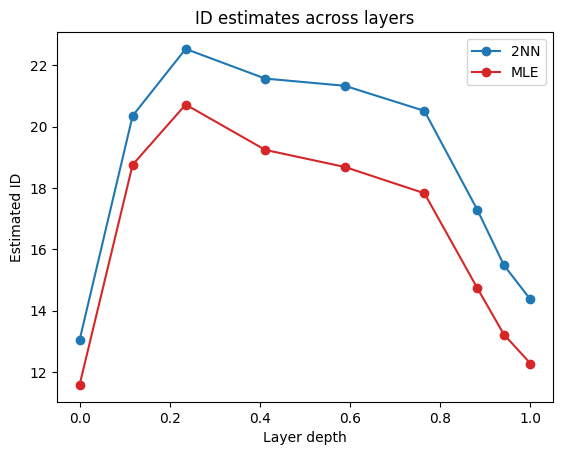

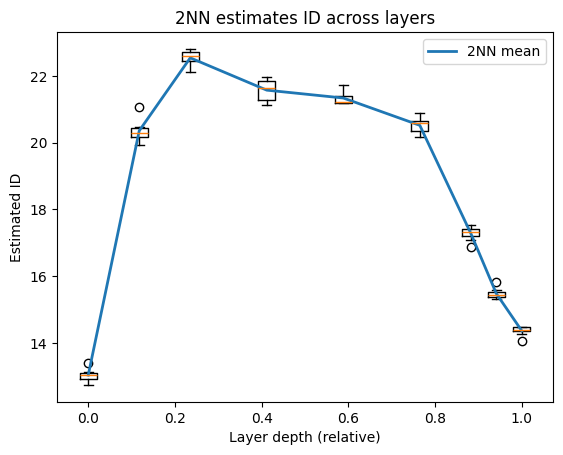

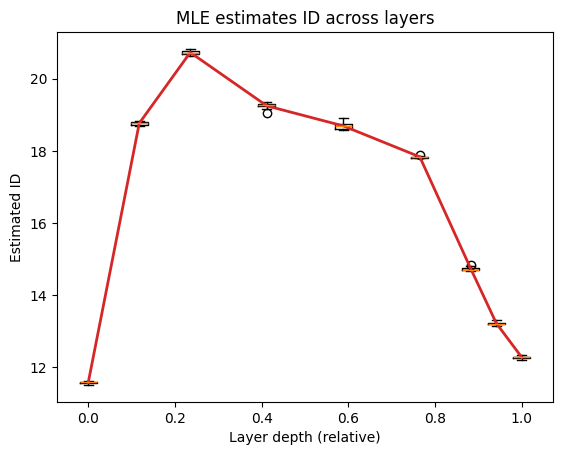

In [ ]:
# --- 2. Model Setup (VGG16) ---
vgg16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
vgg16.eval()
vgg16.to(device)

model = {"vgg16":vgg16}
estimators = {"TwoNN": partial(twonn_id,device=device,batch=512,subsample=0.85),
              "MLE": partial(mle_id,device=device,batch=512,subsample=0.85)}
depth_fns = {
    "vgg16":getDepths
}

# --- 3. Layer-wise ID Extraction Loop ---
R = 8
id_2nn = []
id_mle = []
for i in range(R):
    id_temp = compute_id_dynamics_across_models(model,estimators,loader,depth_fns,device)
    id_2nn.append(id_temp["vgg16"]["TwoNN"])
    id_mle.append(id_temp["vgg16"]["MLE"])
depths = id_temp["vgg16"]["depths"]



# --- 4. Visualization ---
rel = depths/depths[-1]

plt.figure()
plt.plot(rel,np.array(id_2nn).mean(axis=0), color='C0', marker='o', label="2NN")
plt.plot(rel,np.array(id_mle).mean(axis=0), color='C3', marker='o', label="MLE")
plt.xlabel("Layer depth")
plt.ylabel("Estimated ID")
plt.title("ID estimates across layers")
plt.legend()
plt.show()


plt.figure()
bp_2nn = plt.boxplot(
    np.array(id_2nn),
    positions=rel,
    widths=0.04,
    patch_artist=False,
    manage_ticks=False
)
plt.plot(rel, np.array(id_2nn).mean(axis=0), color="C0", linewidth=2, label="2NN mean")
plt.xlabel("Layer depth (relative)")
plt.ylabel("Estimated ID")
plt.title("2NN estimates ID across layers")
plt.legend()
plt.show()


plt.figure()
bp_mle = plt.boxplot(
    np.asarray(id_mle),
    positions=rel,
    widths=0.04,
    patch_artist=False,
    manage_ticks=False
)

plt.plot(rel, np.array(id_mle).mean(axis=0), color="C3", linewidth=2, label="MLE mean")
plt.xlabel("Layer depth (relative)")
plt.ylabel("Estimated ID")
plt.title("MLE estimates ID across layers")
plt.show()


### Observation
*   Across layers, the estimated intrinsic dimension typically rises in early layers, stays roughly flat in the middle, and drops in the later layers, both the 2NN and MLE estimators converge toward values close to 16, which indicates partial alignment with the true intrinsic dimensionality of the input data.
*   Although the match is not exact across all layers, the overall trajectory is consistent with prior findings: networks tend to expand and unfold factors of variation in the early/middle layers, then suppress nuisances, and finally compress representations to support linear separability.